# Credit Default Prediction

This notebook focuses on predicting credit card default using customer financial data. The objective is to understand how factors such as demographics, credit limits, and repayment behaviour influence the probability of default in the following month.
The analysis follows a structured approach:
- Understanding the dataset
- Exploring patterns through visualisations
- Preparing and cleaning the data
- Training machine learning models
- Evaluating and comparing their performance
- Interpreting the results

## 1. Load Dataset


In [175]:
# Imports Libraries
import pandas as pd

# Data manipulation
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing & splitting
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Machine learning evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

# Handling class imbalance
!pip install -q imbalanced-learn
from imblearn.over_sampling import SMOTE

# Explainability
!pip install -q lime
from lime.lime_tabular import LimeTabularExplainer
import shap

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [176]:
df = pd.read_excel("default of credit card clients.xls", header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Basic Inspection
* The dataset has 30,000 customers (rows) and 25 features (columns)

* All columns have 30,000 non-null values, meaning there are no missing values in this dataset.

* Statistical summary for all numerical columns. This helps us understand the range of credit limits, typical bill amounts, typical payment amounts, and distribution of customer ages. This gives an idea of customer financial behaviour.

In [177]:
# Shape of dataset
df.shape

(30000, 25)

In [178]:
# Data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [179]:
# Statistical summary
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [180]:
# Columns
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [181]:
# Duplicate
df.duplicated().sum()

np.int64(0)

Key columns include:
* LIMIT_BAL → credit limit
* SEX, EDUCATION, MARRIAGE, AGE → demographic data
* PAY_0 to PAY_6 → past payment history
* BILL_AMT1 to BILL_AMT6 → past bill statements
* PAY_AMT1 to PAY_AMT6 → past payments
* default payment next month → target variable

##3. Identify Target Variable
The result shows approximately 78% did not default while 22% defaulted. This shows class imbalance. This is very important because a model could predict “no default” for everyone and still be 78% accurate. Therefore, accuracy is not a reliable metric for this problem

In [182]:
# Distribution of target variable
df['default payment next month'].value_counts(normalize=True)

,proportion
default payment next month,
0,0.7788
1,0.2212


In [183]:
# Check for missing values
df.isnull().sum().sum()

np.int64(0)

##4. Feature Distributions

This plot shows the distribution of all numerical variables, helping to understand their range, identify skewness, and detect potential outliers in the dataset.

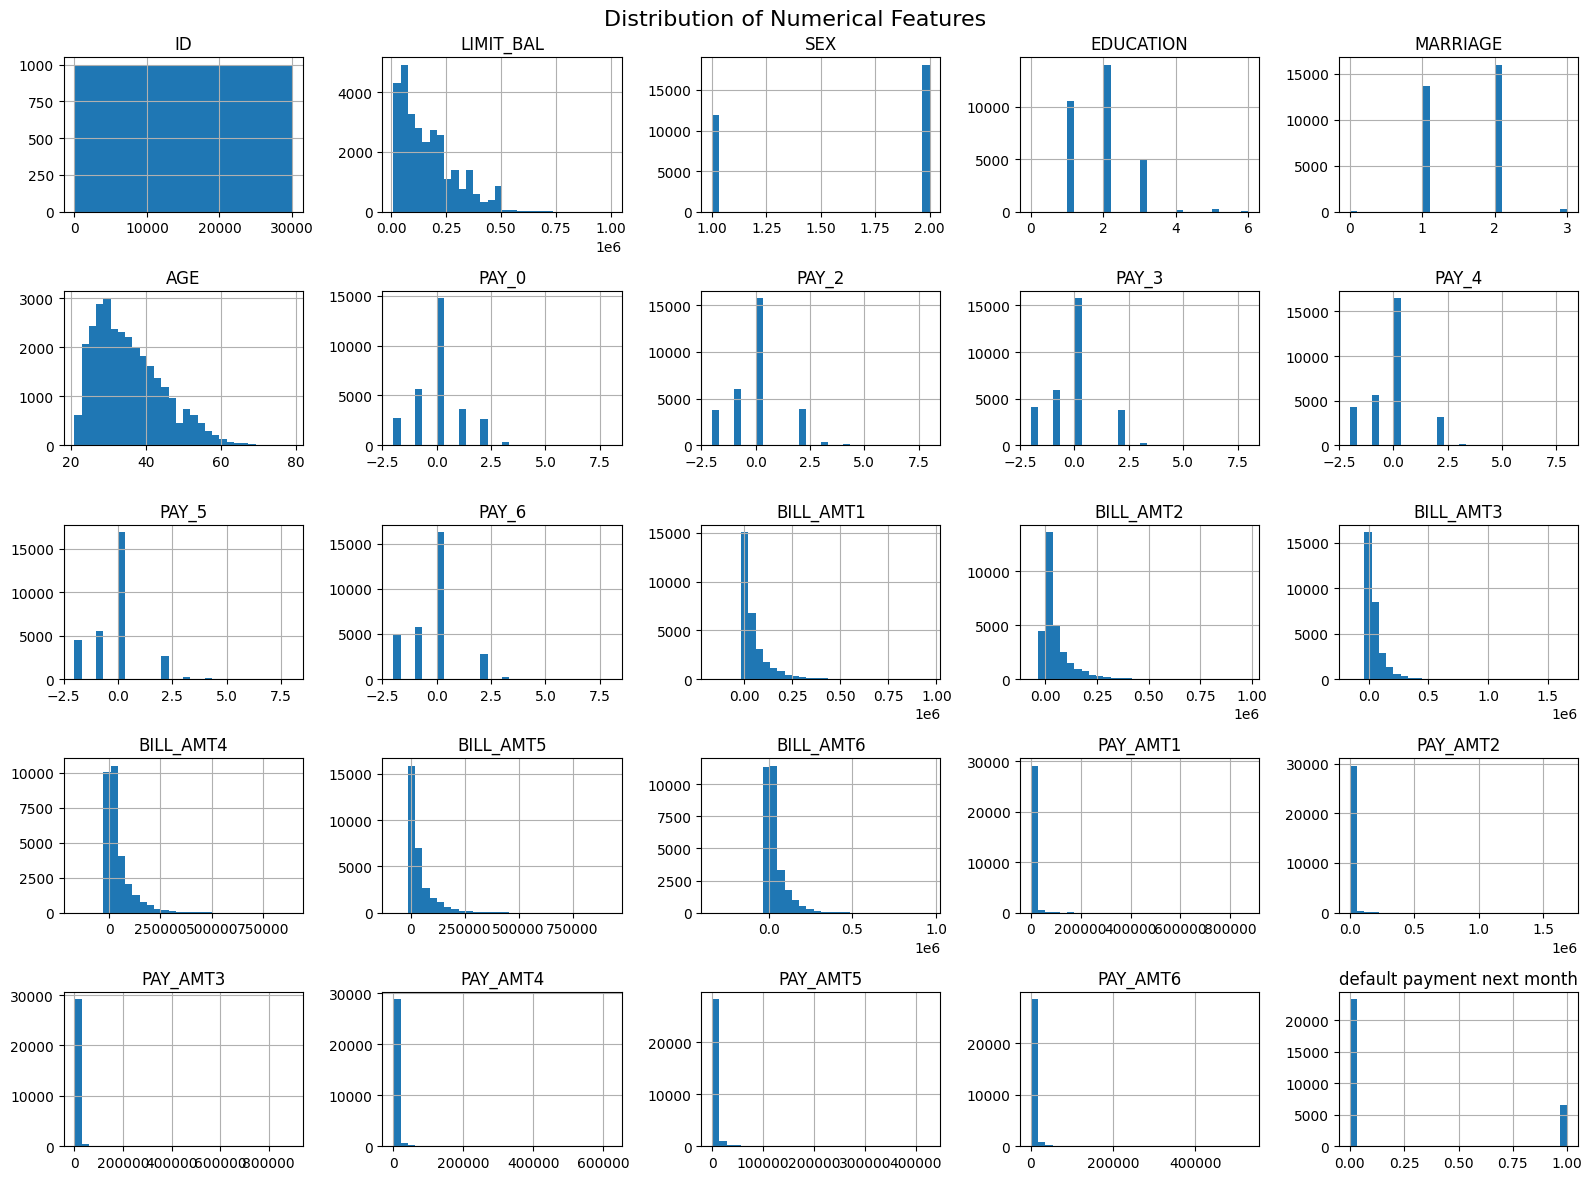

In [184]:
# Plot distributions of all numerical features
df.hist(figsize=(16, 12), bins=30)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

##5. Correlation Analysis
The correlation matrix highlights relationships between variables and helps identify which features are strongly associated with default.

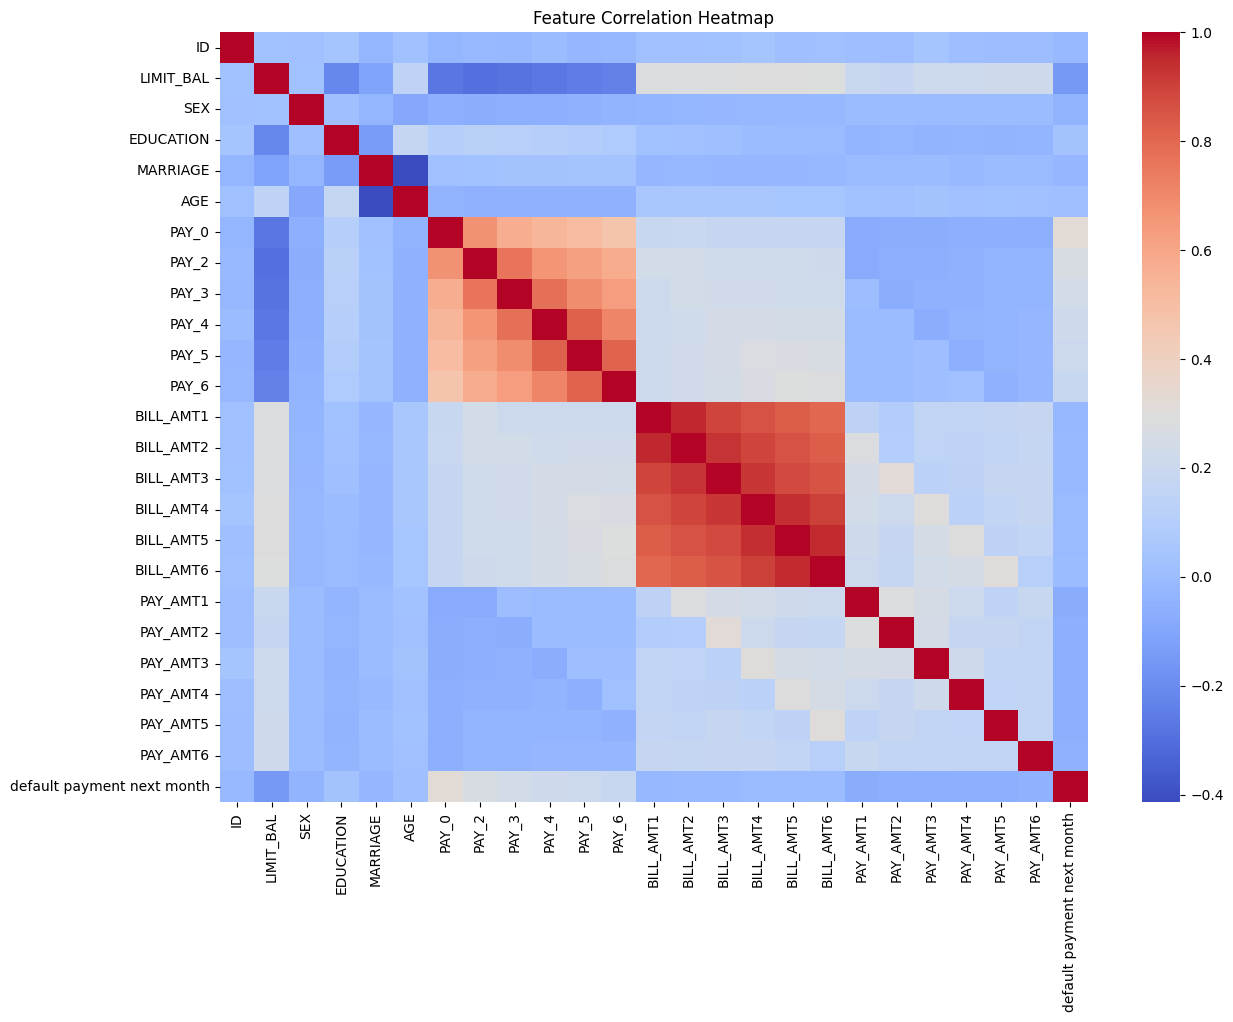

In [185]:
# Visualizing relationships between all variables
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

Pearson correlation coefficients (from -1 to +1):
* Red (close to +1): strong positive relationship
* Blue (close to -1): strong negative relationship
* White/light: little or no relationship

Repayment history (PAY_0–PAY_6) shows strongest relationship with default

##6. Class Distribution Plot
This is a visual confirmation of the class imbalance, and so late payment behaviour directly leads to higher default risk.

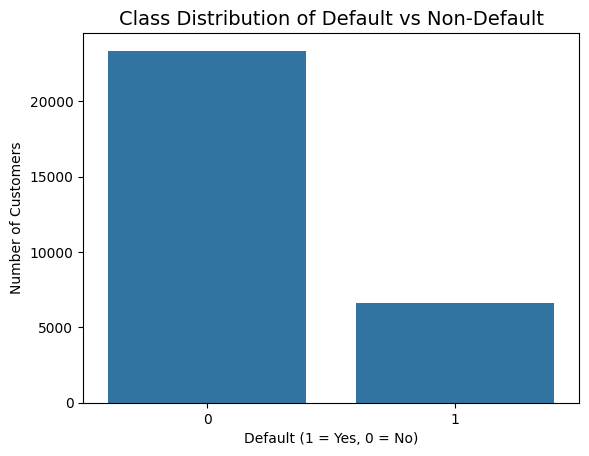

In [186]:
# Plot class distribution of the target variable
sns.countplot(x='default payment next month', data=df)
plt.title("Class Distribution of Default vs Non-Default", fontsize=14)
plt.xlabel("Default (1 = Yes, 0 = No)")
plt.ylabel("Number of Customers")
plt.show()

Severe class imbalance: approximately 78% non-default vs 22% default

##7. Data Preparation and Feature Engineering


#### **a. Data Preparation**

ID is only an identifier and contains no useful information for prediction.
Removing it prevents the model from learning meaningless patterns.

In [187]:
# Drop ID column
df.drop('ID', axis=1, inplace=True)

In [188]:
# Check missing values
df.isnull().sum()

,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0
PAY_5,0


In [189]:
# Check for duplicate rows in the dataset
df.duplicated().sum()

np.int64(35)

In [190]:
# Check if duplicates exist
df.drop_duplicates(inplace=True)

####**b. Fix Data Types**

#####**b.i. Categorical Feature Handling**

Some columns are categorical but stored as numbers, so I convert them.

Examples: SEX, EDUCATION, MARRIAGE.

In [191]:
# Convert selected columns to categorical type for proper handling of nominal variables
categorical_cols = ['SEX','EDUCATION','MARRIAGE']

for col in categorical_cols:
    df[col] = df[col].astype('category')

#####**b.ii. Handle Class Imbalance**

Earlier EDA showed 23% defaults, 77% non-defaults so later in the code I'll use SMOTE to balance the data.

In [192]:
# Display class proportions to quantify the target imbalance
df['default payment next month'].value_counts(normalize=True)

,proportion
default payment next month,
0,0.778742
1,0.221258


#####**c. Feature Engineering**

Create new useful variables; these features help models understand customer behaviour.

In [193]:
# Total Bill Amount
df['TOTAL_BILL'] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                       'BILL_AMT4','BILL_AMT5','BILL_AMT6']].sum(axis=1)

In [194]:
# Total Payment
df['TOTAL_PAY'] = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                      'PAY_AMT4','PAY_AMT5','PAY_AMT6']].sum(axis=1)

In [195]:
# Payment Ratio
df['PAY_RATIO'] = df['TOTAL_PAY'] / df['TOTAL_BILL'].replace(0,1)

##8. Train/Test Split

The data is split into 80% for training and 20% for testing to ensure good generalisation. The `stratify=y` parameter is used to preserve the class distribution in both sets.


In [196]:
# Split data into train and test sets using stratification to preserve the class imbalance in both sets
X = df.drop('default payment next month', axis=1)
y = df['default payment next month']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

Encode categorical data:

* Converts categorical columns into numeric columns.

* "align" ensures train/test have the same columns.

In [197]:
# One-hot encode categorical variables and align train/test columns to avoid mismatch
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc = pd.get_dummies(X_test, drop_first=True)

X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

##9. Handling Class Imbalance

In this part, I handle class imbalance by applying SMOTE to the training data, generating synthetic examples of the minority class to create a balanced dataset before training the models.

In [198]:
# Apply SMOTE to handle class imbalance by generating synthetic samples
sm = SMOTE(random_state=42)

# Fit SMOTE on training data and resample to create a balanced dataset
X_train_sm, y_train_sm = sm.fit_resample(X_train_enc, y_train)

# Display class distribution before applying SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

# Display class distribution after applying SMOTE
print("After SMOTE:")
print(y_train_sm.value_counts())

# Define ROC-AUC as the evaluation metric
scoring = 'roc_auc'

Before SMOTE:
default payment next month
0    18668
1     5304
Name: count, dtype: int64
After SMOTE:
default payment next month
0    18668
1    18668
Name: count, dtype: int64


## 10. Train ML Models

Five different machine learning models are used to predict credit default:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost

Each model will be briefly introduced to highlight its main characteristics.

In [154]:
# Baseline models
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

# Function to evaluate models
def evaluate_model(name, model):
    model.fit(X_train_sm, y_train_sm)

    y_pred = model.predict(X_test_enc)
    y_prob = model.predict_proba(X_test_enc)[:,1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

# Evaluate all baseline models
baseline_results = []

for name, model in baseline_models.items():
    baseline_results.append(evaluate_model(name, model))

baseline_df = pd.DataFrame(baseline_results).set_index("Model").round(4)

# Sort by ROC-AUC
baseline_df.sort_values(by="ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Gradient Boosting,0.8096,0.5975,0.4276,0.4985,0.7584
XGBoost,0.8013,0.5723,0.4027,0.4728,0.7500
Random Forest,0.7988,0.5596,0.4246,0.4828,0.7484
Logistic Regression,0.6219,0.3249,0.6576,0.4349,0.6994
Decision Tree,0.7060,0.3584,0.4163,0.3852,0.6022


##11. Hyperparameter Tuning

I try different parameter values for each model and keep the version that performs best.

#### **a. Logistic Regression Tuning**

In [155]:
# Hyperparameter tuning for Logistic Regression
lr_params = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs']
}

lr_grid = RandomizedSearchCV(
    LogisticRegression(max_iter=2000),
    lr_params,
    cv=3,
    random_state=42,
    n_iter=5,
    scoring=scoring,
    n_jobs=-1
)

# Train
lr_grid.fit(X_train_sm, y_train_sm)

# Choosing the best parameters
best_lr = lr_grid.best_estimator_
print("Best LR Params:", lr_grid.best_params_)

# Predict labels and probabilities
y_pred_lr = best_lr.predict(X_test_enc)
y_prob_lr = best_lr.predict_proba(X_test_enc)[:,1]

# Print evaluation results
print("Logistic Regression Results (Tuned)")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Best LR Params: {'solver': 'lbfgs', 'C': 10}
Logistic Regression Results (Tuned)
[[2281 2386]
 [ 347  979]]
              precision    recall  f1-score   support

           0       0.87      0.49      0.63      4667
           1       0.29      0.74      0.42      1326

    accuracy                           0.54      5993
   macro avg       0.58      0.61      0.52      5993
weighted avg       0.74      0.54      0.58      5993



#### **b. Decision Tree Tuning**

In [156]:
# Hyperparameter tuning for Decision Tree
dt_params = {
    'max_depth': [5, 10],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4]
}

dt_grid = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=3,
    n_iter=5,
    scoring=scoring,
    n_jobs=-1
)

# Train
dt_grid.fit(X_train_sm, y_train_sm)

# Choosing the best parameters
best_dt = dt_grid.best_estimator_
print("Best DT Params:", dt_grid.best_params_)

# Predict labels and probabilities
y_pred_dt = best_dt.predict(X_test_enc)
y_prob_dt = best_dt.predict_proba(X_test_enc)[:,1]

# Print evaluation results
print("Decision Tree Results (Tuned)")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Best DT Params: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}
Decision Tree Results (Tuned)
[[4148  519]
 [ 753  573]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      4667
           1       0.52      0.43      0.47      1326

    accuracy                           0.79      5993
   macro avg       0.69      0.66      0.67      5993
weighted avg       0.78      0.79      0.78      5993



#### **c. Random Forest Tuning**

In [157]:
# Hyperparameter tuning for Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

rf_grid = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=3,
    n_iter=5,
    scoring=scoring,
    n_jobs=-1
)

# Train
rf_grid.fit(X_train_sm, y_train_sm)

# Choosing the best parameters
best_rf = rf_grid.best_estimator_
print("Best RF Params:", rf_grid.best_params_)

# Predict labels and probabilities
y_pred_rf = best_rf.predict(X_test_enc)
y_prob_rf = best_rf.predict_proba(X_test_enc)[:,1]

# Print evaluation results
print("Random Forest Results (Tuned)")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Best RF Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Random Forest Results (Tuned)
[[4222  445]
 [ 755  571]]
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      4667
           1       0.56      0.43      0.49      1326

    accuracy                           0.80      5993
   macro avg       0.71      0.67      0.68      5993
weighted avg       0.78      0.80      0.79      5993



#### **d. Gradient Boosting Tuning**

In [158]:
# Hyperparameter tuning for Gradient Boosting
gb_params = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3]
}

gb_grid = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=3,
    n_iter=5,
    scoring=scoring,
    n_jobs=-1
)

# Train
gb_grid.fit(X_train_sm, y_train_sm)

# Choosing the best parameters
best_gb = gb_grid.best_estimator_
print("Best GB Params:", gb_grid.best_params_)

# Predict labels and probabilities
y_pred_gb = best_gb.predict(X_test_enc)
y_prob_gb = best_gb.predict_proba(X_test_enc)[:,1]

# Print evaluation results
print("Gradient Boosting Results (Tuned)")
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Best GB Params: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.05}
Gradient Boosting Results (Tuned)
[[4272  395]
 [ 761  565]]
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      4667
           1       0.59      0.43      0.49      1326

    accuracy                           0.81      5993
   macro avg       0.72      0.67      0.69      5993
weighted avg       0.79      0.81      0.80      5993



#### **e. XGBoost Tuning**

In [159]:
# Hyperparameter tuning for XGBoost
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

xgb_grid = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    xgb_params,
    cv=3,
    n_iter=5,
    scoring=scoring,
    n_jobs=-1
)

# Train
xgb_grid.fit(X_train_sm, y_train_sm)

# Choosing the best parameters
best_xgb = xgb_grid.best_estimator_
print("Best XGB Params:", xgb_grid.best_params_)

# Predict labels and probabilities
y_pred_xgb = best_xgb.predict(X_test_enc)
y_prob_xgb = best_xgb.predict_proba(X_test_enc)[:,1]

# Print evaluation results
print("XGBoost Results (Tuned)")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Best XGB Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
XGBoost Results (Tuned)
[[4297  370]
 [ 779  547]]
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      4667
           1       0.60      0.41      0.49      1326

    accuracy                           0.81      5993
   macro avg       0.72      0.67      0.68      5993
weighted avg       0.79      0.81      0.79      5993



##12. Model Performance Comparison

After training the five models, I compare which one performed best.

### a. Performance Metrics

After training and evaluating the five machine learning models, their performance was compared using several evaluation metrics.

These metrics include:
Accuracy, Precision, Recall, F1-score, ROC-AUC


In [160]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_xgb)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_xgb)
    ]
}

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df.sort_values(by="ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
XGBoost,0.8083,0.5965,0.4125,0.4877,0.7614
Gradient Boosting,0.8071,0.5885,0.4261,0.4943,0.7561
Random Forest,0.7998,0.5620,0.4306,0.4876,0.7513
Decision Tree,0.7878,0.5247,0.4321,0.4739,0.7118
Logistic Regression,0.5440,0.2909,0.7383,0.4174,0.6644


### b. Confusion Matrices

Confusion matrices were used to evaluate model performance in more detail. They show the number of true positives, true negatives, false positives, and false negatives for each model. This helps to understand not only overall accuracy, but also how well the models identify defaults and avoid misclassification.




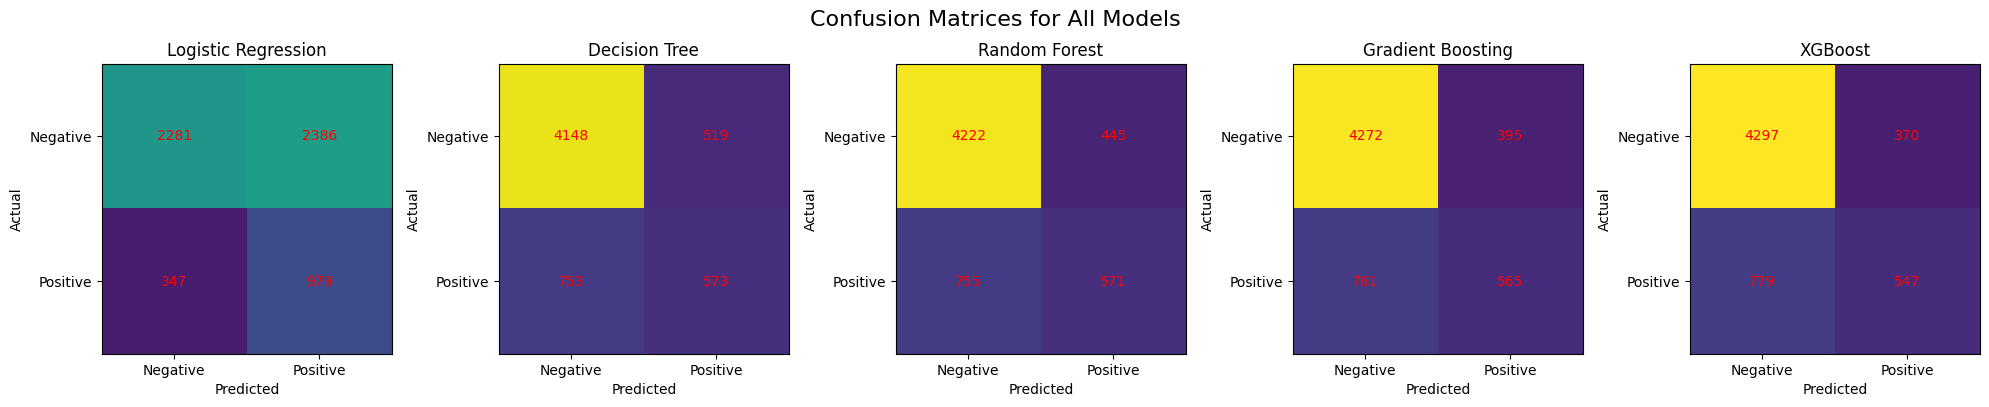

In [199]:
# Compute confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_gb = confusion_matrix(y_test, y_pred_gb)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# List for easy loop
cms = [cm_lr, cm_dt, cm_rf, cm_gb, cm_xgb]
titles = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "XGBoost"
]

# Create figure
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Common color scale (important for fair comparison)
vmin = 0
vmax = max(cm.max() for cm in cms)

# Labels
labels = ["Negative", "Positive"]

for i, (cm, title) in enumerate(zip(cms, titles)):
    ax = axes[i]
    im = ax.imshow(cm, vmin=vmin, vmax=vmax)

    # Title
    ax.set_title(title)

    # Axis labels
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    # Ticks
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Add values inside boxes
    for j in range(2):
        for k in range(2):
            ax.text(k, j, cm[j, k], ha="center", va="center", color="red")

plt.suptitle("Confusion Matrices for All Models", fontsize=16)
plt.tight_layout()
plt.show()

### c. ROC Curve

To compare model performance, ROC curves were plotted. They show the trade-off between true positive rate and false positive rate across thresholds. The ROC-AUC summarises performance, with higher values indicating better class discrimination.

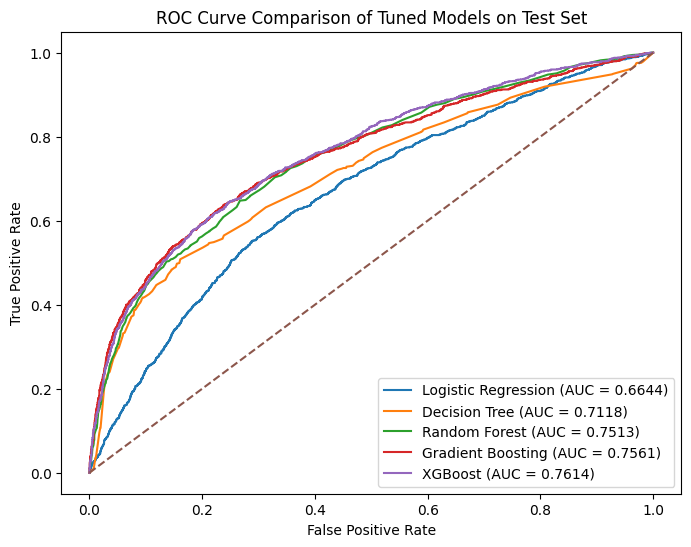

In [162]:
plt.figure(figsize=(8,6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})')

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.4f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})')

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, y_prob_gb):.4f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.4f})')

# Random guess line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Tuned Models on Test Set")
plt.legend()
plt.show()

##13. Feature Importance Analysis

Feature importance analysis helps identify which variables contribute the most to the model’s predictions.

Understanding feature importance is particularly valuable in financial risk modelling because it provides insights into the key factors associated with credit default.
I'm identifying which features are important for each model.


#### **a. Logistic Regression Feature Importance**

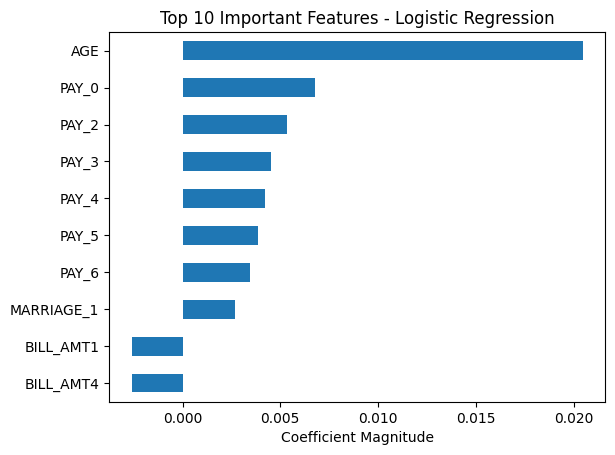

In [163]:
lr_coeff = pd.Series(
    best_lr.coef_[0],
    index=X_train_enc.columns
).sort_values(key=abs, ascending=False)

lr_coeff.head(10)

lr_coeff.head(10).plot(kind='barh')
plt.xlabel("Coefficient Magnitude")
plt.title("Top 10 Important Features - Logistic Regression")
plt.gca().invert_yaxis()
plt.show()

#### **b. Decision Tree Feature Importance**

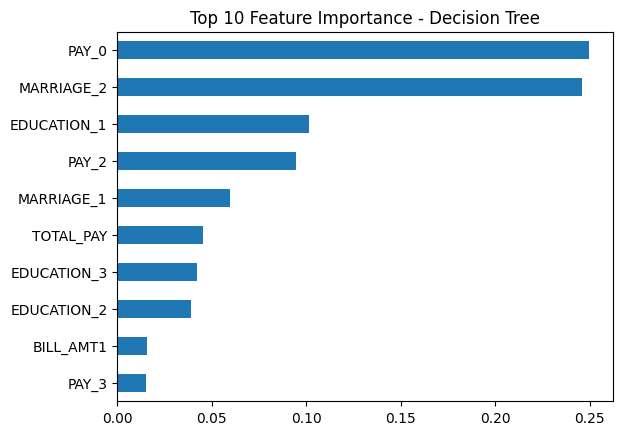

In [164]:
# Create and sort decision tree feature importance scores
dt_importance = pd.Series(
    best_dt.feature_importances_,
    index=X_train_enc.columns
).sort_values(ascending=False)

# Show top 10 features
dt_importance.head(10)

# Plot top 10 features
dt_importance.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importance - Decision Tree")
plt.gca().invert_yaxis()
plt.show()

#### **c. Random Forest Feature Importance**

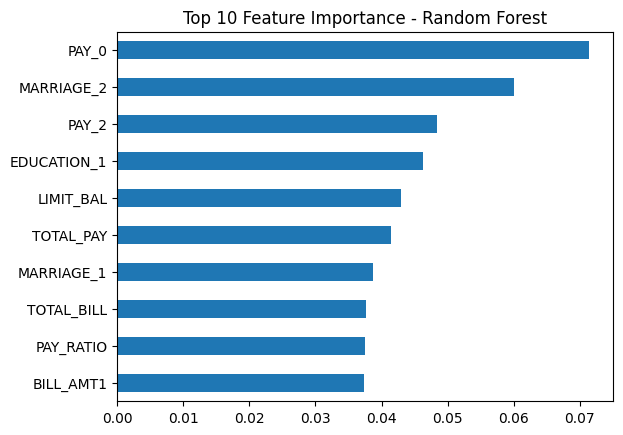

In [165]:
# Create and sort random forest feature importance scores
rf_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train_enc.columns
).sort_values(ascending=False)

# Show top 10 most important features
rf_importance.head(10)

# Plot top 10 random forest feature importances
rf_importance.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

#### **d. Gradient Boosting Feature Importance**

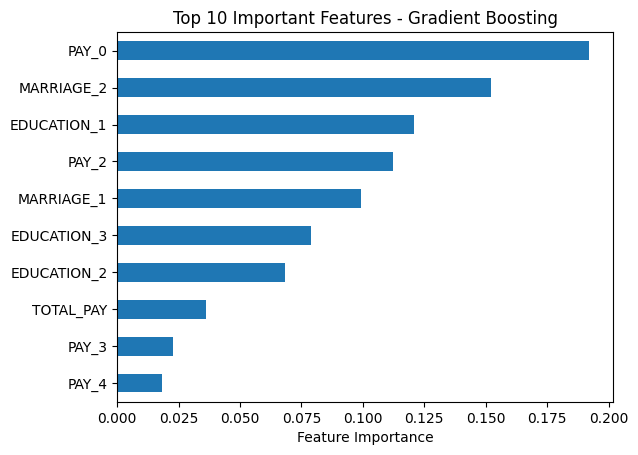

In [166]:
# Create and sort gradient boosting feature importance scores
gb_importance = pd.Series(
    best_gb.feature_importances_,
    index=X_train_enc.columns
).sort_values(ascending=False)

# Show top 10 important features
gb_importance.head(10)

# Plot top 10 feature importances
gb_importance.head(10).plot(kind='barh')
plt.xlabel("Feature Importance")
plt.title("Top 10 Important Features - Gradient Boosting")
plt.gca().invert_yaxis()
plt.show()

#### **e. XGBoost Feature Importance**

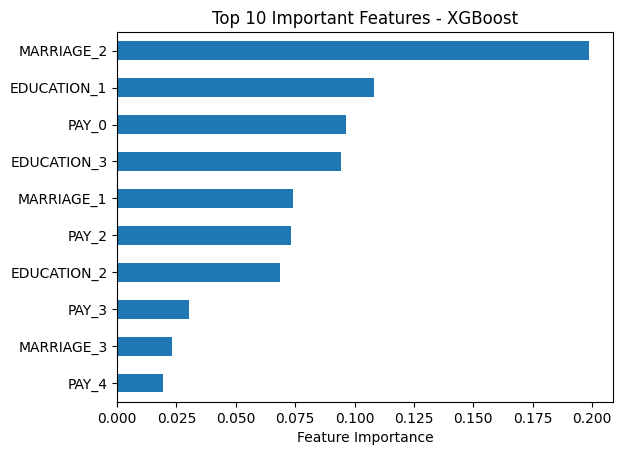

In [167]:
# Create and sort XGBoost feature importance scores
xgb_importance = pd.Series(
    best_xgb.feature_importances_,
    index=X_train_enc.columns
).sort_values(ascending=False)

# Show top 10 important features
xgb_importance.head(10)

# Plot top 10 feature importances
xgb_importance.head(10).plot(kind='barh')
plt.xlabel("Feature Importance")
plt.title("Top 10 Important Features - XGBoost")
plt.gca().invert_yaxis()
plt.show()

##14. Model Interpretability (Explainable AI)


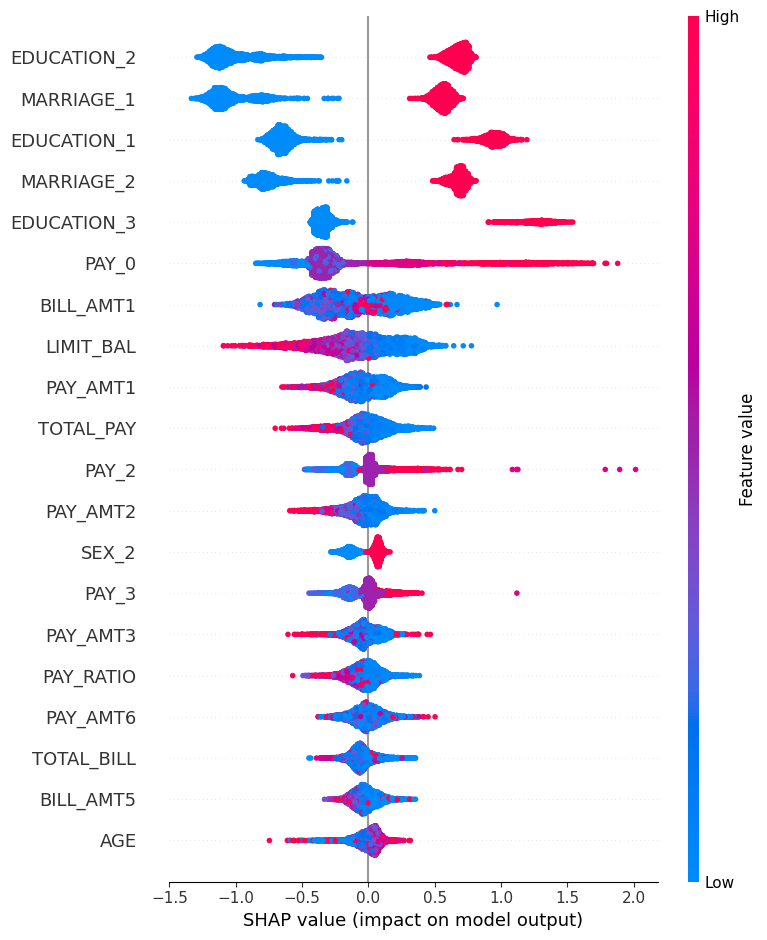

In [168]:
# Create explainer for the tuned XGBoost model
explainer = shap.TreeExplainer(best_xgb)

# Compute SHAP values on the test set
shap_values = explainer.shap_values(X_test_enc)

# Summary plot
shap.summary_plot(shap_values, X_test_enc)

This plot shows:

* Feature importance

* Whether high or low values increase default risk

* Overall feature impact

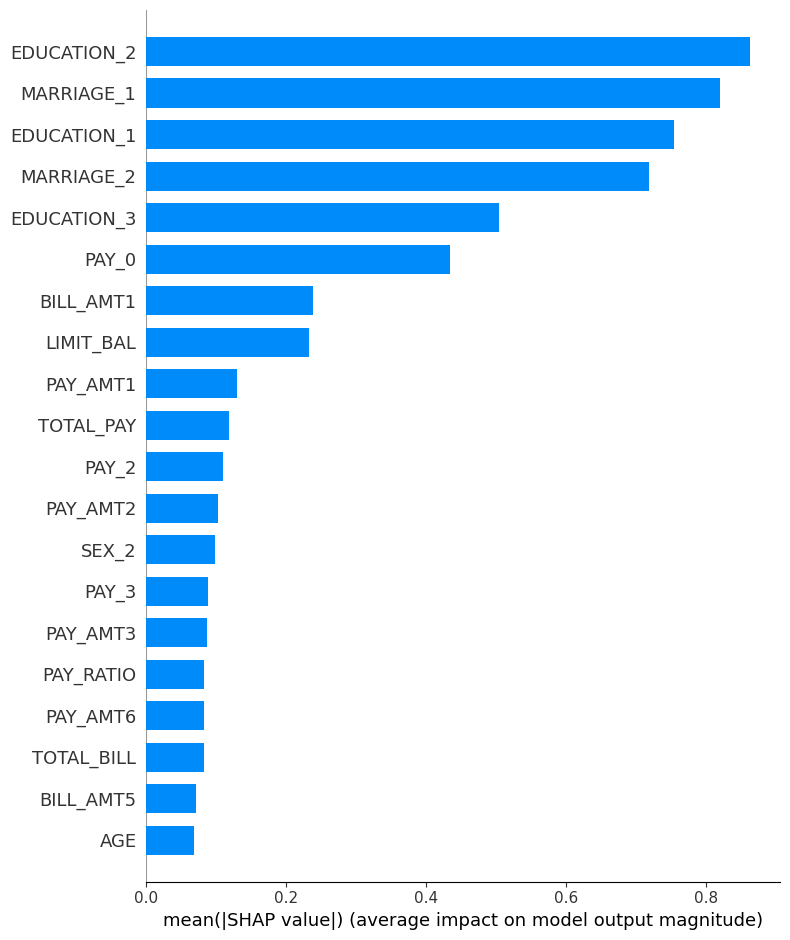

In [169]:
# SHAP Bar Plot
shap.summary_plot(shap_values, X_test_enc, plot_type="bar")

This graph shows:

* Top features influencing predictions

* Global feature importance

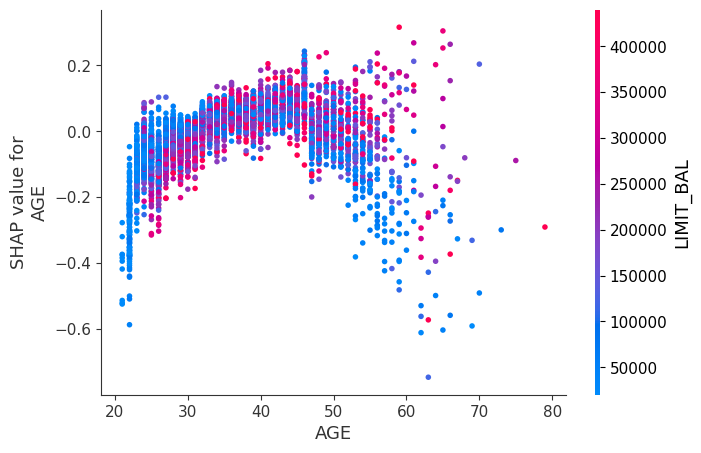

In [170]:
# SHAP Dependence Plot
shap.dependence_plot("AGE", shap_values, X_test_enc)

It shows:

* Relationship between feature value and model prediction

* Feature interactions

In [171]:
# SHAP Force Plot (Individual Prediction)
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_enc.iloc[0]
)


This explains why the model predicted default for one customer. It shows:

* Features pushing prediction toward default

* Features pushing prediction toward non-default

In [172]:
# Create the LIME Explainer (Local Explanation)
explainer = LimeTabularExplainer(
    training_data=X_train_sm.values,
    feature_names=X_train_sm.columns,
    class_names=['No Default','Default'],
    mode='classification'
)

Explanation:

* training_data → your balanced dataset

* feature_names → column names

* class_names → prediction classes

In [173]:
#  Explain One Prediction
exp = explainer.explain_instance(
    X_test_enc.iloc[0].values,
    best_xgb.predict_proba
)

In [174]:
# Display the Explanation
exp.show_in_notebook()

This will generate a visual explanation showing:

* Features increasing default risk
* Features decreasing default risk

Meaning:

* Large loans increase default risk

* Low credit score increases default risk

* Higher income reduces risk

## 15. Conclusion

This project aimed to predict whether a customer will default on their credit card payment using the Default of Credit Card Clients dataset from the UCI Machine Learning Repository.

Exploratory data analysis revealed strong relationships among repayment history variables (PAY_0 to PAY_6), bill amounts (BILL_AMT1 to BILL_AMT6), and payment amounts (PAY_AMT1 to PAY_AMT6). Most importantly, repayment behaviour showed the strongest correlation with default, indicating that customer behaviour over time is more informative than demographic characteristics or credit limit.

The dataset was found to be imbalanced, with significantly more non-default cases than default cases. This justified the use of stratified train-test split, SMOTE to balance the training data, and evaluation metrics such as precision, recall, F1-score, and ROC-AUC instead of accuracy.

Multiple models were trained and tuned, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost. After hyperparameter tuning and evaluation, Gradient Boosting/XGBoost (depending on your best result) achieved the best predictive performance.

Feature importance analysis, along with SHAP and LIME explanations, confirmed that repayment status variables were the most influential predictors of default. These explainability techniques helped interpret both global model behaviour and individual predictions, improving model transparency.

Overall, this project demonstrates that past repayment behaviour is the most reliable indicator of future credit card default, and that combining class balancing, model tuning, and explainable AI techniques leads to a robust and interpretable predictive model.